In [1]:
import os

dataset_root = r"C:\Users\jeff3\Downloads\DeepGuardDB_v1\DeepGuardDB_v1"

print("Dataset root:", dataset_root)
print("Exists?", os.path.isdir(dataset_root))

FOLDERS = {
    "dalle":  os.path.join(dataset_root, "DALLE_dataset"),
    "glide":  os.path.join(dataset_root, "GLIDE_dataset"),
    "imagen": os.path.join(dataset_root, "IMAGEN_dataset"),
    "sd":     os.path.join(dataset_root, "SD_dataset"),
    "json":   os.path.join(dataset_root, "json_files"),
}


def _collect_files(root_dir, exts=(".png", ".jpg", ".jpeg", ".webp")):
    files = []
    if os.path.isdir(root_dir):
        for dirpath, dirnames, filenames in os.walk(root_dir):
            for f in filenames:
                if f.lower().endswith(exts):
                    files.append(os.path.join(dirpath, f))
    return files


def load_all_data():
    data = {}

    for name, root in FOLDERS.items():
        if name == "json":
            continue

        real_dir = os.path.join(root, "real")
        fake_dir = os.path.join(root, "fake")

        real_files = _collect_files(real_dir)
        fake_files = _collect_files(fake_dir)

        data[name] = {"real": real_files, "fake": fake_files}

    return data


def load_dataset(name):
    root = FOLDERS[name]

    if name == "json":
        all_files = []
        for dirpath, dirnames, filenames in os.walk(root):
            for f in filenames:
                all_files.append(os.path.join(dirpath, f))
        return {"all": all_files}

    real_dir = os.path.join(root, "real")
    fake_dir = os.path.join(root, "fake")

    real_files = _collect_files(real_dir)
    fake_files = _collect_files(fake_dir)

    if real_files or fake_files:
        return {"real": real_files, "fake": fake_files}

    all_files = []
    for dirpath, dirnames, filenames in os.walk(root):
        for f in filenames:
            all_files.append(os.path.join(dirpath, f))

    return {"all": all_files}


Dataset root: C:\Users\jeff3\Downloads\DeepGuardDB_v1\DeepGuardDB_v1
Exists? True


In [2]:
from PIL import Image
from sklearn.decomposition import PCA
def sample_images(n):

    all_data = load_all_data()
    datasets = ['dalle','glide','imagen','sd']
    all_samples = {}

    for i in datasets:
        real = all_data[i]['real'] #call real 1
        fake = all_data[i]['fake'] #call fake 0
        real_sample = real[:n]
        fake_sample = fake[:n]

        for path in real_sample:
            all_samples[path] =1

        for path in fake_sample:
            all_samples[path] = 0

    return all_samples

def apply_gray_scale_pca(all_samples, size, n_components):
    inputs = []
    labels = []
    for path, label in all_samples.items():
        img = Image.open(path).convert("L")     #gray scale according to my notes below
        img = img.resize(size)                  #512x512
        arr = np.asarray(img) / 255.0           #normalizes
        inputs.append(arr.flatten())            #flattens
        labels.append(label)
    x = np.vstack(inputs) #fpr 2d
    y = np.array(labels, dtype = int)

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    pca_model = PCA(n_components)
    x_pca = pca_model.fit_transform(x_scaled)

    return x_pca, y, scaler, pca_model

def apply_RGB_scale_pca(all_samples, size, n_components):
    inputs = []
    labels = []
    for path, label in all_samples.items():
        img = Image.open(path).convert("RGB")   #RGB scale according to my notes below
        img = img.resize(size)                  #512x512
        arr = np.asarray(img) / 255.0           #normalizes
        inputs.append(arr.flatten())            #flattens
        labels.append(label)
    x = np.vstack(inputs) #fpr 2d
    y = np.array(labels, dtype = int)

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    pca_model = PCA(n_components)
    x_pca = pca_model.fit_transform(x_scaled)

    return x_pca, y, scaler, pca_model

def apply_patch_pca(all_samples, size, patch_size, n_components): #Patch using RGB. Evaluates using local pixels nearby rather than global pixels approach with PCA.
    ph, pw = patch_size

    items = list(all_samples.items())  #(path, label)

    patch_list = []
    patches_per_image = []
    labels = []

    # loop through each img
    for path, label in items:
        img = Image.open(path).convert("RGB") #RGB scale
        img = img.resize(size)
        arr = np.asarray(img) / 255.0

        H, W , C = arr.shape
        #ensure each are returning RGB images

        nrows, ncols = H // ph, W // pw

        arr = arr[:nrows*ph, :ncols*pw]

        count_patches = 0
        for ii in range(nrows):
            for jj in range(ncols):
                block = arr[ii*ph:(ii+1)*ph, jj*pw:(jj+1)*pw, :]
                vec = block.reshape(-1, order='F')
                patch_list.append(vec)
                count_patches += 1

        patches_per_image.append(count_patches)
        labels.append(label)

    X_patches = np.vstack(patch_list)
    y = np.array(labels, dtype=int)

    scaler = StandardScaler()
    X_patches_scaled = scaler.fit_transform(X_patches)

    pca_model = PCA(n_components=n_components)
    X_patches_pca = pca_model.fit_transform(X_patches_scaled)

    num_images = len(items)
    X_img = np.zeros((num_images, n_components))

    # combine the imgs back together
    idx = 0
    for i in range(num_images):
        m = patches_per_image[i]           # how many patches in this image
        feat_patches = X_patches_pca[idx:idx+m]  # (m, n_components)
        X_img[i, :] = feat_patches.mean(axis=0)
        idx += m

    return X_img, y, scaler, pca_model

In [3]:
# training file for the knn model
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression



def run_knn(x, y, n_neighbors=5):
    data = load_all_data()

    dalle_real = data["dalle"]["real"]
    dalle_fake = data["dalle"]["fake"]

    # print("Dalle REAL images:", len(dalle_real))
    # print("Dalle FAKE images:", len(dalle_fake))

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean", weights="uniform")
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    print("KNN accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

    return knn

def run_logistic_regression(x, y):
    data = load_all_data()

    dalle_real = data["dalle"]["real"]
    dalle_fake = data["dalle"]["fake"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    LR = LogisticRegression(max_iter=1000, penalty = "l2", C = 1.0, solver = 'lbfgs')
    LR.fit(x_train,y_train)

    y_pred = LR.predict(x_test)

    print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

    return LR




if __name__ == "__main__":
    samples = sample_images(20)

    x_gray_pca, y, gray_scaler, gray_pca_model = apply_gray_scale_pca(samples, size = (128,128), n_components=50)
    # print("PCA shape:", x_pca.shape)
    # print("y shape:", y.shape)

    x_rgb_pca, y, rgb_scaler, RGB_pca_model = apply_RGB_scale_pca(samples, size = (128,128), n_components=50)
    # print("PCA shape:", x_pca.shape)
    # print("y shape:", y.shape)

    x_patch_pca, y, patch_scaler, patch_pca_model = apply_patch_pca(samples, size=(128, 128), patch_size=(8, 8), n_components=50)
    # print("Patch-PCA feature shape:", x_patch_pca.shape)
    # print("Labels shape:", y.shape)

    knn_model = run_knn(x_patch_pca, y, n_neighbors=5)
    knn_model_2 = run_knn(x_gray_pca, y, n_neighbors=5)
    knn_model_3 = run_knn(x_rgb_pca, y, n_neighbors=5)

    LR_gray  = run_logistic_regression(x_gray_pca, y)
    LR_rgb   = run_logistic_regression(x_rgb_pca, y)
    LR_patch = run_logistic_regression(x_patch_pca, y)

#dictionary to classify what dataset it came from
# do a pca transformation channel by channel. so we treat each column channel as an independent gary scale image.

KNN accuracy: 0.53125
Confusion matrix:
 [[ 6 10]
 [ 5 11]]
Classification report:
               precision    recall  f1-score   support

           0       0.55      0.38      0.44        16
           1       0.52      0.69      0.59        16

    accuracy                           0.53        32
   macro avg       0.53      0.53      0.52        32
weighted avg       0.53      0.53      0.52        32

KNN accuracy: 0.4375
Confusion matrix:
 [[ 5 11]
 [ 7  9]]
Classification report:
               precision    recall  f1-score   support

           0       0.42      0.31      0.36        16
           1       0.45      0.56      0.50        16

    accuracy                           0.44        32
   macro avg       0.43      0.44      0.43        32
weighted avg       0.43      0.44      0.43        32

KNN accuracy: 0.5
Confusion matrix:
 [[ 4 12]
 [ 4 12]]
Classification report:
               precision    recall  f1-score   support

           0       0.50      0.25      0.33 

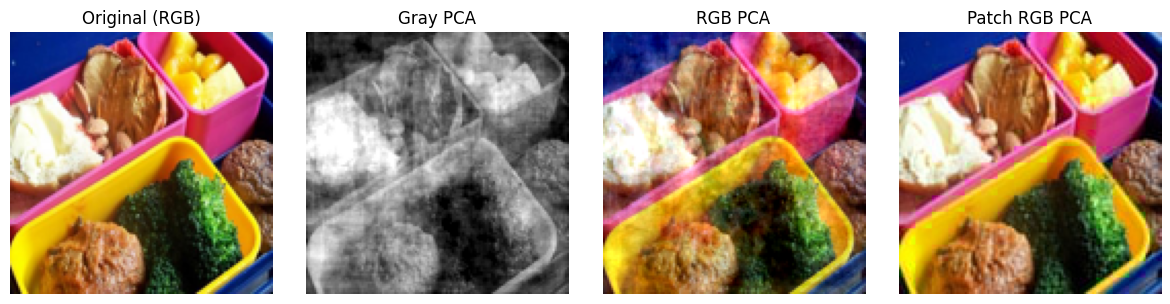

In [4]:
import matplotlib.pyplot as plt
def reconstruct_gray_from_pca(path, size, scaler, pca_model):
    img = Image.open(path).convert("L")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    H, W = arr.shape

    x = arr.flatten()[None, :]
    x_scaled = scaler.transform(x)
    z = pca_model.transform(x_scaled)
    x_scaled_rec = z @ pca_model.components_ + pca_model.mean_
    x_rec = scaler.inverse_transform(x_scaled_rec)
    arr_rec = x_rec.reshape(H, W)
    arr_rec = np.clip(arr_rec, 0.0, 1.0)
    return arr_rec


def reconstruct_rgb_from_pca(path, size, scaler, pca_model):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    H, W, C = arr.shape

    x = arr.flatten()[None, :]
    x_scaled = scaler.transform(x)
    z = pca_model.transform(x_scaled)
    x_scaled_rec = z @ pca_model.components_ + pca_model.mean_
    x_rec = scaler.inverse_transform(x_scaled_rec)
    arr_rec = x_rec.reshape(H, W, C)
    arr_rec = np.clip(arr_rec, 0.0, 1.0)
    return arr_rec


def reconstruct_patch_from_pca(path, size, patch_size, scaler, pca_model):
    ph, pw = patch_size
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    H, W, C = arr.shape
    nrows, ncols = H // ph, W // pw
    arr = arr[: nrows * ph, : ncols * pw, :]

    patches = []
    for ii in range(nrows):
        for jj in range(ncols):
            block = arr[ii * ph : (ii + 1) * ph,
                        jj * pw : (jj + 1) * pw,
                        :]
            patches.append(block.reshape(-1, order="F"))

    X = np.vstack(patches)
    X_scaled = scaler.transform(X)
    Z = pca_model.transform(X_scaled)

    X_scaled_rec = Z @ pca_model.components_ + pca_model.mean_
    X_rec = scaler.inverse_transform(X_scaled_rec)

    rec = np.zeros_like(arr)
    idx = 0
    for ii in range(nrows):
        for jj in range(ncols):
            vec = X_rec[idx]
            block = vec.reshape(ph, pw, 3, order="F")
            rec[ii * ph : (ii + 1) * ph,
                jj * pw : (jj + 1) * pw,
                :] = block
            idx += 1

    rec = np.clip(rec, 0.0, 1.0)
    return rec
first_path = list(samples.keys())[0]

if __name__ == "__main__":
    # Original RGB image
    orig_img = Image.open(first_path).convert("RGB").resize((128, 128))
    orig_arr = np.asarray(orig_img, dtype=np.float32) / 255.0

    # Reconstructions
    rec_gray = reconstruct_gray_from_pca(first_path, (128, 128),
                                         gray_scaler, gray_pca_model)
    rec_rgb = reconstruct_rgb_from_pca(first_path, (128, 128),
                                       rgb_scaler, RGB_pca_model)
    rec_patch = reconstruct_patch_from_pca(first_path, (128, 128),
                                           (8, 8), patch_scaler, patch_pca_model)

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 4, 1)
    plt.title("Original (RGB)")
    plt.imshow(orig_arr)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Gray PCA")
    plt.imshow(rec_gray, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("RGB PCA")
    plt.imshow(rec_rgb)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Patch RGB PCA")
    plt.imshow(rec_patch)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def run_xgboost(x, y):
    # stratified split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        tree_method='hist'        
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    return model


In [8]:
if __name__ == "__main__":
    samples = sample_images(2000)

    x_gray_pca, y, gray_scaler, gray_pca_model = apply_gray_scale_pca(samples, (128,128), 50)
    x_rgb_pca,  y, rgb_scaler, RGB_pca_model   = apply_RGB_scale_pca(samples, (128,128), 50)
    x_patch_pca,y, patch_scaler, patch_pca_model = apply_patch_pca(samples, (128,128), (8,8), 50)

    print("\nRunning XGBoost on Gray PCA features:")
    xgb_gray = run_xgboost(x_gray_pca, y)

    print("\nRunning XGBoost on RGB PCA features:")
    xgb_rgb = run_xgboost(x_rgb_pca, y)

    print("\nRunning XGBoost on Patch PCA features:")
    xgb_patch = run_xgboost(x_patch_pca, y)



Running XGBoost on Gray PCA features:
XGBoost Accuracy: 0.6995594713656388
Confusion Matrix:
 [[797 338]
 [344 791]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70      1135
           1       0.70      0.70      0.70      1135

    accuracy                           0.70      2270
   macro avg       0.70      0.70      0.70      2270
weighted avg       0.70      0.70      0.70      2270


Running XGBoost on RGB PCA features:
XGBoost Accuracy: 0.6973568281938326
Confusion Matrix:
 [[787 348]
 [339 796]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.69      0.70      1135
           1       0.70      0.70      0.70      1135

    accuracy                           0.70      2270
   macro avg       0.70      0.70      0.70      2270
weighted avg       0.70      0.70      0.70      2270


Running XGBoost on Patch PCA features:
XGBoost Accuracy: 0.677

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform, filters, feature
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def extract_spatial_features(all_samples,size=(128, 128),lbp_P=8,lbp_R=1,hog_pixels_per_cell=(16, 16),hog_cells_per_block=(2, 2),hog_orientations=9):

    X_list = []
    y_list = []

    for path, label in all_samples.items():
        img = io.imread(path)

        if img.ndim == 3:
            img_gray = color.rgb2gray(img)
        else:
            img_gray = img.astype(np.float32)
            if img_gray.max() > 1.0:
                img_gray = img_gray / 255.0

        img_gray = transform.resize(
            img_gray,
            size,
            anti_aliasing=True
        ).astype(np.float32)

        img_gray_uint = (img_gray * 255).astype(np.uint8)

        sobel = filters.sobel(img_gray)
        lap   = filters.laplace(img_gray, ksize=3)

        #fingerprint the images for ai.
        sobel_mean = sobel.mean()
        sobel_std  = sobel.std()
        sobel_max  = sobel.max()

        lap_mean = lap.mean()
        lap_std  = lap.std()

        sobel_lap_feats = np.array(
            [sobel_mean, sobel_std, sobel_max, lap_mean, lap_std],
            dtype=np.float32
        )

        lbp = feature.local_binary_pattern(
            img_gray_uint,
            P=lbp_P,
            R=lbp_R,
            method="uniform"
        )

        lbp_hist, _ = np.histogram(
            lbp.ravel(),
            bins=10,
            range=(0, 10),
            density=True
        )

        hog_vec = feature.hog(
            img_gray,
            orientations=hog_orientations,
            pixels_per_cell=hog_pixels_per_cell,
            cells_per_block=hog_cells_per_block,
            block_norm="L2-Hys",
            feature_vector=True
        )

        feats = np.concatenate([sobel_lap_feats, lbp_hist.astype(np.float32), hog_vec.astype(np.float32)])
        X_list.append(feats)
        y_list.append(label)

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=int)
    return X, y


def extract_fourier_features(all_samples,size=(128, 128),fft_size=32):
    X_list = []
    y_list = []

    for path, label in all_samples.items():
        img = io.imread(path)

        if img.ndim == 3:
            img_gray = color.rgb2gray(img)
        else:
            img_gray = img.astype(np.float32)
            if img_gray.max() > 1.0:
                img_gray = img_gray / 255.0

        img_gray = transform.resize(
            img_gray,
            size,
            anti_aliasing=True
        ).astype(np.float32)

        # shift the low frequency to the center, the compare it with real images to see their differences.
        F = np.fft.fft2(img_gray)
        Fshift = np.fft.fftshift(F)
        mag = np.abs(Fshift)
        mag = np.log1p(mag) 

        H, W = mag.shape
        half = fft_size // 2
        center_h, center_w = H // 2, W // 2

        mag_crop = mag[center_h - half : center_h + half,
                       center_w - half : center_w + half]

        fourier_feats = mag_crop.ravel().astype(np.float32)
        X_list.append(fourier_feats)
        y_list.append(label)

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=int)
    return X, y


def combine_spatial_fourier(X_spatial, X_fourier):
    X = np.hstack([X_spatial, X_fourier])
    return X
 


In [34]:
if __name__ == "__main__":
    samples = sample_images(250)

    X_spatial, y = extract_spatial_features(samples, size=(128, 128))
    X_fourier, y2 = extract_fourier_features(samples, size=(128, 128), fft_size=32)
    X_combined = combine_spatial_fourier(X_spatial, X_fourier)

    print("Spatial features shape:", X_spatial.shape)
    print("Fourier features shape:", X_fourier.shape)
    print("Combined feature shape:", X_combined.shape)

    xgb_model = run_xgboost(X_combined, y)


Spatial features shape: (2000, 1779)
Fourier features shape: (2000, 1024)
Combined feature shape: (2000, 2803)
XGBoost Accuracy: 0.8475
Confusion Matrix:
 [[168  32]
 [ 29 171]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85       200
           1       0.84      0.85      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400

